# Rnnlm

这个 notebook 用来基于 `my-torch-lib` 手动训练第 6.4 节的 LSTM 版语言模型 `Rnnlm`。

这一版只保留代码提示，不提前写实现代码。你需要自己完成每一步训练链路。

模型主干结构是：

- `TimeEmbedding`
- `TimeLSTM(stateful=True)`
- `TimeLinear`

注意：`Rnnlm.forward(xs)` 只返回 logits，loss 在模型外部单独计算。

## 环境准备：说明

这一步的目标是把 notebook 运行环境接到 `deep_learning_implementation`、`my-torch-lib` 和 `my-eval-lib`。

后面需要用到 PTB 数据、LSTM 版 `Rnnlm`、时间版损失层、优化器、梯度裁剪、连续语料 batch helper 和困惑度函数。

In [1]:
from pathlib import Path
import time
import sys
import random
import torch
import numpy as np

projects_dir = Path.cwd().resolve().parent.parent
sys.path.insert(0, str(".."))
sys.path.insert(0, str(projects_dir / "my-torch-lib"))
sys.path.insert(0, str(projects_dir / "my-eval-lib"))

from dataset import ptb
from torchlib.models.rnnlm import Rnnlm
from torchlib.layers.softmax_loss import TimeSoftmaxWithLoss
from torchlib.optim.sgd import SGD
from torchlib.utils.grad import clip_grads
from torchlib.utils.rnnlm import create_rnnlm_offsets, create_rnnlm_batch
from eval.metrics import perplexity

## 超参数设置：说明

这一步负责定义训练中会反复使用的核心超参数。

建议先采用较小规模设置，优先保证 notebook 能快速跑通，再逐步接近书中第 6.4 节的配置。

## 超参数设置：TODO

- 设置 `batch_size`。
- 设置 `wordvec_size`。
- 设置 `hidden_size`。
- 设置 `time_size`。
- 设置 `lr`。
- 设置 `max_epoch`。
- 设置 `max_grad`，用于梯度裁剪。
- 设置 `corpus_size`，用于先跑小语料 smoke test。
- 设置 `device`。

自查：`time_size` 和 Truncated BPTT 的展开长度是什么关系？

In [2]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)


batch_size = 20
wordvec_size = 100
hidden_size = 100
time_size = 35
lr = 20.0
max_epoch = 4
corpus_size = None
max_grad = 0.25
device = 'cpu'

## 读取 PTB 数据：说明

这里要从 PTB 训练集取出连续语料。

语言模型常见构造方式是：

- `xs = corpus[:-1]`
- `ts = corpus[1:]`

`xs` 是当前时刻的输入词 ID，`ts` 是下一时刻的目标词 ID。

## 读取 PTB 数据：TODO

- 调用 `ptb.load_data("train")`。
- 按 `corpus_size` 截断语料。
- 构造 `xs = corpus[:-1]`。
- 构造 `ts = corpus[1:]`。
- 计算 `data_size`。
- 计算 `vocab_size`。
- 打印语料长度和词表大小。

自查：为什么 `xs` 和 `ts` 只相差一个时间步？

In [3]:
corpus, word_to_id, id_to_word = ptb.load_data('train')
corpus = corpus[:corpus_size]
xs = corpus[:-1]
ts = corpus[1:]
data_size = len(xs)
vocab_size = len(np.unique(corpus))

## 张量化：说明

这里需要把语料从 NumPy 形式转换成 torch 可直接使用的张量。

当前模型仍然使用词 ID 输入，不需要自己手动构造 one-hot。

## 张量化：TODO

- 将 `xs` 转成整型 torch tensor。
- 将 `ts` 转成整型 torch tensor。
- 如有需要，将张量移动到 `device`。

自查：为什么 Embedding 输入必须是整型词 ID？

In [4]:
xs = torch.tensor(xs, dtype=torch.long)
ts = torch.tensor(ts, dtype=torch.long)

## Offsets 与时间状态：说明

这一步负责初始化连续语料 batch 生成所需的状态。

你需要把一整条语料切成 `batch_size` 条并行子序列，并维护一个跨 iteration 递增的 `time_idx`。

## Offsets 与时间状态：TODO

- 初始化 `time_idx = 0`。
- 计算 `max_iters = data_size // (batch_size * time_size)`。
- 用 `create_rnnlm_offsets(data_size, batch_size)` 生成 `offsets`。
- 准备 `loss_list` 或后续统计用的列表。

自查：为什么连续语料训练时 `time_idx` 不应该在每个 iteration 重置？

In [5]:
time_idx = 0
max_iters = data_size // (batch_size * time_size)
offsets = create_rnnlm_offsets(data_size, batch_size)

## 初始化模型、损失与优化器：说明

这里要把模型本体、损失层和优化器准备好。

`Rnnlm` 只负责返回 logits；`TimeSoftmaxWithLoss` 在模型外部接收 logits 和标签计算 loss。

## 初始化模型、损失与优化器：TODO

- 实例化 `Rnnlm(vocab_size, wordvec_size, hidden_size)`。
- 将模型移动到 `device`。
- 实例化 `TimeSoftmaxWithLoss()`。
- 实例化 `SGD(model.parameters(), lr)`。

自查：为什么这里不把 loss 写进 `Rnnlm.forward()`？

In [6]:
model = Rnnlm(vocab_size, wordvec_size, hidden_size, stateful=True).to(device)
criterion = TimeSoftmaxWithLoss().to(device)
optimizer = SGD(model.parameters(), lr)

## 单步 Batch 演示：说明

在进入完整训练循环前，先单独调一次 `create_rnnlm_batch(...)`。

这一格的重点是理解：`offsets`、`time_idx`、`time_size` 和尾部回绕逻辑。

## 单步 Batch 演示：TODO

- 调一次 `create_rnnlm_batch(...)`。
- 检查 `batch_x` 的 shape 是否为 `(batch_size, time_size)`。
- 检查 `batch_t` 的 shape 是否为 `(batch_size, time_size)`。
- 检查 `next_time_idx` 是否按 `time_size` 向前推进。

自查：为什么 batch 中每一行是从不同 offset 开始的连续子序列？

In [7]:
batch_x, batch_t, next_time_idx = create_rnnlm_batch(xs, ts, batch_size, time_size, time_idx, offsets)

In [8]:
batch_x.shape

torch.Size([20, 35])

In [9]:
batch_t.shape

torch.Size([20, 35])

## 单步训练函数：说明

这一步把一次参数更新的流程集中起来，方便完整训练循环复用。

推荐顺序是：前向得到 logits、模型外部计算 loss、清梯度、反向传播、梯度裁剪、更新参数、截断 LSTM 状态。

## 单步训练函数：TODO

- 调用 `model(batch_x)` 得到 `logits`。
- 调用 `criterion(logits, batch_t)` 得到 `loss`。
- 调用 `optimizer.zero_grad()`。
- 调用 `loss.backward()`。
- 调用 `clip_grads(model.parameters(), max_grad)`。
- 调用 `optimizer.step()`。
- 调用 `model.truncate_state()`。
- 返回当前 `loss`。

自查：为什么 stateful LSTM 在每个分段训练后需要 `truncate_state()`？

In [10]:
def train(batch_x, batch_t):
    batch_x = batch_x.to(device)
    batch_t = batch_t.to(device)

    logits = model(batch_x)
    loss = criterion(logits, batch_t)

    optimizer.zero_grad()
    loss.backward()
    clip_grads(model.parameters(), max_grad)
    optimizer.step()

    model.truncate_state()

    return loss, model

## 训练循环：说明

这是 notebook 的主体部分。

训练循环需要持续推进 `time_idx`，让每个 batch 都接续上一段连续语料，同时记录 loss 用于后续计算困惑度。

## 训练循环：TODO

- 写 epoch 循环。
- 写 iter 循环。
- 每次调用 `create_rnnlm_batch(...)` 取 `batch_x`、`batch_t` 和新的 `time_idx`。
- 必要时将 batch 移动到 `device`。
- 调用单步训练函数。
- 将 `loss.item()` 记录到 `loss_list`。
- 可选：按 `eval_interval` 打印平均 loss 或 perplexity。

自查：`logits` 的 shape 应该是什么？

In [11]:
def print_train_progress(epoch, i, max_iters, loss, loss_list, start_time, interval=500):
    count = epoch * max_iters + i + 1
    if count % interval != 0:
        return

    elapsed_time = time.time() - start_time
    recent_loss = np.mean(loss_list[-interval:])
    ppl = np.exp(recent_loss)


    print(
        f"| epoch {epoch + 1:>2d} "
        f"| iter {i + 1:>5d} / {max_iters:<5d} "
        f"| step {count:>6d} "
        f"| time {elapsed_time:>6.0f}[s] "
        f"| loss {loss.item():>7.4f} "
        f"| perplexity {ppl:>8.2f}"
    )

    return loss_list

In [12]:
start_time = time.time()
loss_list = []
for epoch in range(max_epoch):
    for i in range(max_iters):
        batch_x, batch_t, time_idx = \
            create_rnnlm_batch(xs, ts, batch_size, time_size, time_idx, offsets)
        loss, model = train(batch_x, batch_t)
        loss_list.append(loss.item())

        print_train_progress(
            epoch=epoch,
            i=i,
            max_iters=max_iters,
            loss=loss,
            loss_list=loss_list,
            start_time=start_time,
            interval=100,
        )

| epoch  1 | iter   100 / 1327  | step    100 | time     10[s] | loss  6.4168 | perplexity  1161.31
| epoch  1 | iter   200 / 1327  | step    200 | time     21[s] | loss  6.2749 | perplexity   621.57
| epoch  1 | iter   300 / 1327  | step    300 | time     31[s] | loss  5.9347 | perplexity   484.13
| epoch  1 | iter   400 / 1327  | step    400 | time     41[s] | loss  5.6230 | perplexity   387.77
| epoch  1 | iter   500 / 1327  | step    500 | time     52[s] | loss  5.8525 | perplexity   338.35
| epoch  1 | iter   600 / 1327  | step    600 | time     62[s] | loss  5.6756 | perplexity   309.22
| epoch  1 | iter   700 / 1327  | step    700 | time     72[s] | loss  5.8041 | perplexity   273.14
| epoch  1 | iter   800 / 1327  | step    800 | time     82[s] | loss  5.3437 | perplexity   241.88
| epoch  1 | iter   900 / 1327  | step    900 | time     93[s] | loss  5.5768 | perplexity   232.93
| epoch  1 | iter  1000 / 1327  | step   1000 | time    103[s] | loss  5.3824 | perplexity   228.89


## 困惑度计算：说明

这里不要再写模型调用流程。

`perplexity` 应该作为纯指标函数，基于已记录的 loss 统计量计算。

## 困惑度计算：TODO

- 将 `loss_list` 转成 NumPy 数组。
- 基于每次迭代 loss 或平均 loss 调用 `perplexity(...)`。
- 保存 `ppl_list`。
- 打印最终训练困惑度。

自查：困惑度下降说明模型学到了什么？

In [13]:
loss_list = np.array(loss_list)

ppl_list = perplexity(loss_list)
# perplexity(loss_list.mean())
ppl_list[-1]

np.float64(100.94668964395396)

## 绘图：说明

训练跑完后，把困惑度曲线画出来。

重点不是图多漂亮，而是确认训练曲线有没有明显异常。

## 绘图：TODO

- 生成横轴序号。
- 用 `matplotlib` 画出 perplexity 曲线。
- 补上标题、坐标轴标签和图例。
- 检查曲线是否整体下降。

自查：如果曲线不下降，你会优先排查数据、loss、状态还是学习率？

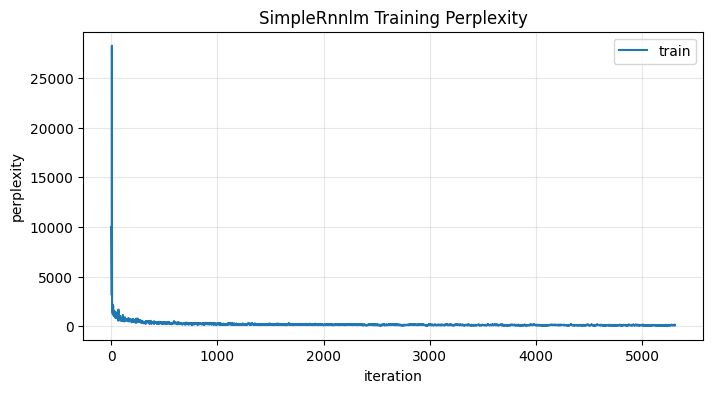

In [14]:
import matplotlib.pyplot as plt

ppl_values = np.atleast_1d(np.asarray(ppl_list, dtype=float))
x = np.arange(1, len(ppl_values) + 1)
x_label = 'epoch' if len(ppl_values) == max_epoch else 'iteration'

plt.figure(figsize=(8, 4))
plt.plot(x, ppl_values, label='train')
plt.title('SimpleRnnlm Training Perplexity')
plt.xlabel(x_label)
plt.ylabel('perplexity')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 结果反思：说明

`Rnnlm` 是把上一章 SimpleRnnlm 中的 `TimeRNN` 换成 `TimeLSTM` 后的语言模型。

这一节的重点是确认你是否理解 LSTM 训练链路中新增的状态、梯度裁剪和截断反向传播。

## 结果反思：TODO

- 总结 `Rnnlm` 相比 `SimpleRnnlm` 的核心变化。
- 总结梯度裁剪在第 6.4 节训练中的作用。
- 总结 `model.truncate_state()` 对 stateful LSTM 的意义。
- 记录当前实现中最容易出错的 1 到 2 个点。

自查：如果下一步实现 BetterRnnlm，哪些训练代码可以继续复用？